____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, compute_mean_square

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Drifters

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4', 'swot2kmnaive_1', 'swot2kmnaive_-1', 'swot2kmnaive_2', 'swot2kmnaive_-2', 'swot2kmnaive_3', 'swot2kmnaive_-3', 'swot2kmnaive_4', 'swot2kmnaive_-4']),
 dict_keys(['era5']))

_______
# Count 

In [13]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'swot2kmnaive_-1', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'swot2kmnaive_1', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'swot2kmnaive_2', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive_-2', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive_3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive_-3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive_4', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive_-4', wd_key = 'era5', ggd_var='etaf', wd_depth='0')]

Ds = []
Dm = []
for comb in comb_list :
    DS = dataset_coloc_combs([comb], nearest =False).dropna('row_number')
    err_acc_update = np.array(err_acc)[np.isin(err_acc, DS.row_number)]
    DS = DS.drop_sel(row_number = err_acc_update)    
    DSS = DS.where(DS.depth==0, drop=True)
    DSS = DSS.where(DSS.pass_number==3, drop=True)
    if 'time_to_swot_update' in DSS:
        DSS['time_to_swot_h'] = DSS['time_to_swot_update']/pd.Timedelta('1h')//1
    else :
        DSS['time_to_swot_h'] = DSS['time_to_swot']/pd.Timedelta('1h')//1
    list_h = np.unique(DSS.time_to_swot_h)
    
    D = []
    for dt in list_h:
        D.append(DSS.where(DSS.time_to_swot_h == dt))
    
    dss = xr.concat(D, dim = pd.Index(list_h, name = 'T'))
    Ds.append(dss)
    ds = compute_mean_square(dss)/U2
    ds = ds.drop_vars('nb_coloc').isel(id_comb=0)
    d = [dss.sel(T=i).dropna('row_number').sizes['row_number'] for i in dss.T]
    ds['nb_coloc']= xr.DataArray(d, dims='T')

    Dm.append(ds)

nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot2kmnaive_-1_etaf__rio_0era5
nofilter__swot2kmnaive_1_etaf__rio_0era5
nofilter__swot2kmnaive_2_etaf__rio_0era5
nofilter__swot2kmnaive_-2_etaf__rio_0era5
nofilter__swot2kmnaive_3_etaf__rio_0era5
nofilter__swot2kmnaive_-3_etaf__rio_0era5
nofilter__swot2kmnaive_4_etaf__rio_0era5
nofilter__swot2kmnaive_-4_etaf__rio_0era5


In [4]:
ds0 = Dm[0].sel(T=np.arange(0,11))
ds1 = (Dm[1].sel(T=np.arange(12,36))*Dm[1].nb_coloc + Dm[2].sel(T=np.arange(12,36))*Dm[2].nb_coloc)/(Dm[1].nb_coloc + Dm[2].nb_coloc)
ds2 = (Dm[3].sel(T=np.arange(36, 60))*Dm[3].nb_coloc + Dm[4].sel(T=np.arange(36, 60))*Dm[4].nb_coloc)/(Dm[3].nb_coloc + Dm[4].nb_coloc)
ds3 = (Dm[5].sel(T=np.arange(60,84))*Dm[5].nb_coloc + Dm[6].sel(T=np.arange(60, 84))*Dm[6].nb_coloc)/(Dm[5].nb_coloc + Dm[6].nb_coloc)
ds4 = (Dm[7].sel(T=np.arange(84, 108))*Dm[7].nb_coloc + Dm[8].sel(T=np.arange(84, 108))*Dm[8].nb_coloc)/(Dm[7].nb_coloc + Dm[8].nb_coloc)
ds1['nb_coloc'] = Dm[1].nb_coloc + Dm[2].nb_coloc
ds2['nb_coloc'] = Dm[3].nb_coloc + Dm[4].nb_coloc
ds3['nb_coloc'] = Dm[5].nb_coloc + Dm[6].nb_coloc
ds4['nb_coloc'] = Dm[7].nb_coloc + Dm[8].nb_coloc
ds = xr.concat([ds0, ds1, ds2, ds3, ds4], dim='T')
ds['T'] = (ds.T/24).assign_attrs({'long_name':'Drifter-altimetry time gap', 'units':'day'})

Text(0.5, 1.0, 'Distribution per 1h-time gap bins')

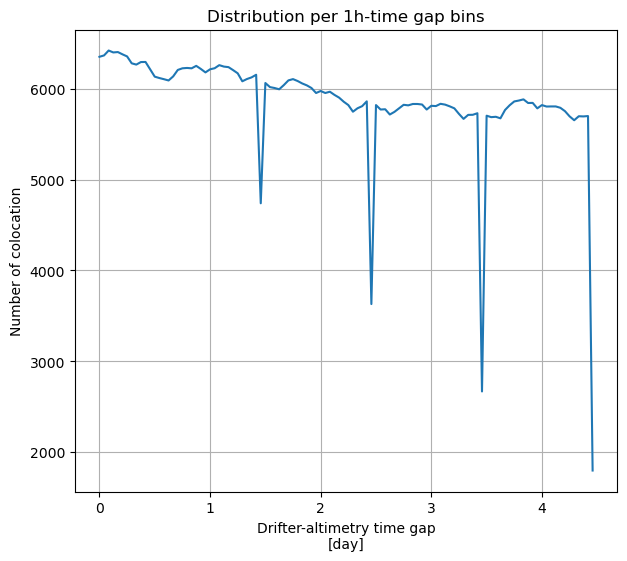

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(7,6))
ds.nb_coloc.plot(ax=ax)
ax.grid()
ax.set_ylabel('Number of colocation')
ax.set_title('Distribution per 1h-time gap bins') 

__________________
## Pair's contributions

In [6]:
Xn = [k for k in ds.keys() if 'Xn' in k]
Xe = [k for k in ds.keys() if 'Xe' in k]

Xe

['Xe_acc_cor',
 'Xe_acc_ggd',
 'Xe_acc_wd',
 'Xe_cor_ggd',
 'Xe_cor_wd',
 'Xe_ggd_wd']

In [7]:
xstyle = {l.replace('Xn_', '') : dict(color=c0[l.split('_')[1]], marker="x", markeredgecolor=c0[l.split('_')[2]], markersize=3) for l in Xn}


Text(0.5, 1.0, 'Total')

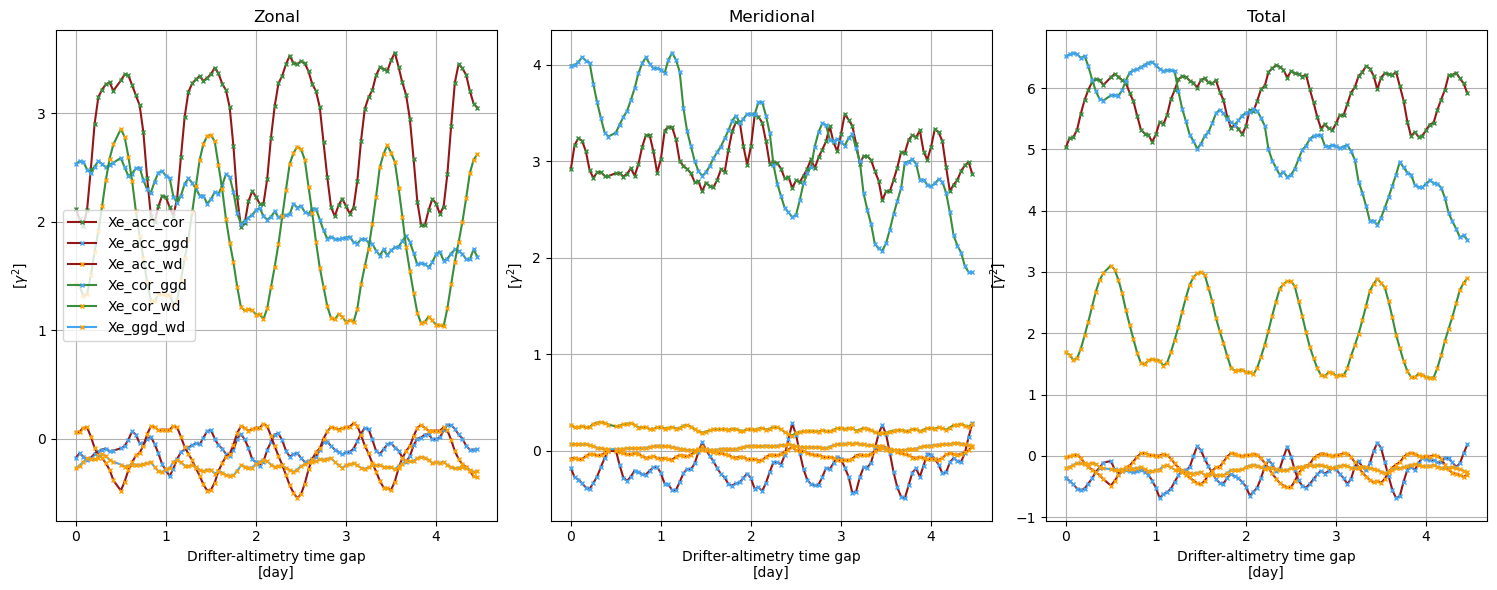

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15,6))
axs =axs.flatten()
for xn in Xn:
    ds[xn].plot(ax=axs[1], label=xn, **xstyle[xn.replace('Xn_', '')])
for xe in Xe:
    ds[xe].plot(ax=axs[0], label=xe, **xstyle[xe.replace('Xe_', '')])
i=0
for xn in Xn:
    (ds[xn] +ds[Xe[i]]).plot( ax=axs[2], label=xn, **xstyle[xn.replace('Xn_', '')])
    i+=1
    
fig.tight_layout()
for ax in axs:
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
axs[0].legend()

axs[0].set_title('Zonal')
axs[1].set_title('Meridional')
axs[2].set_title('Total')



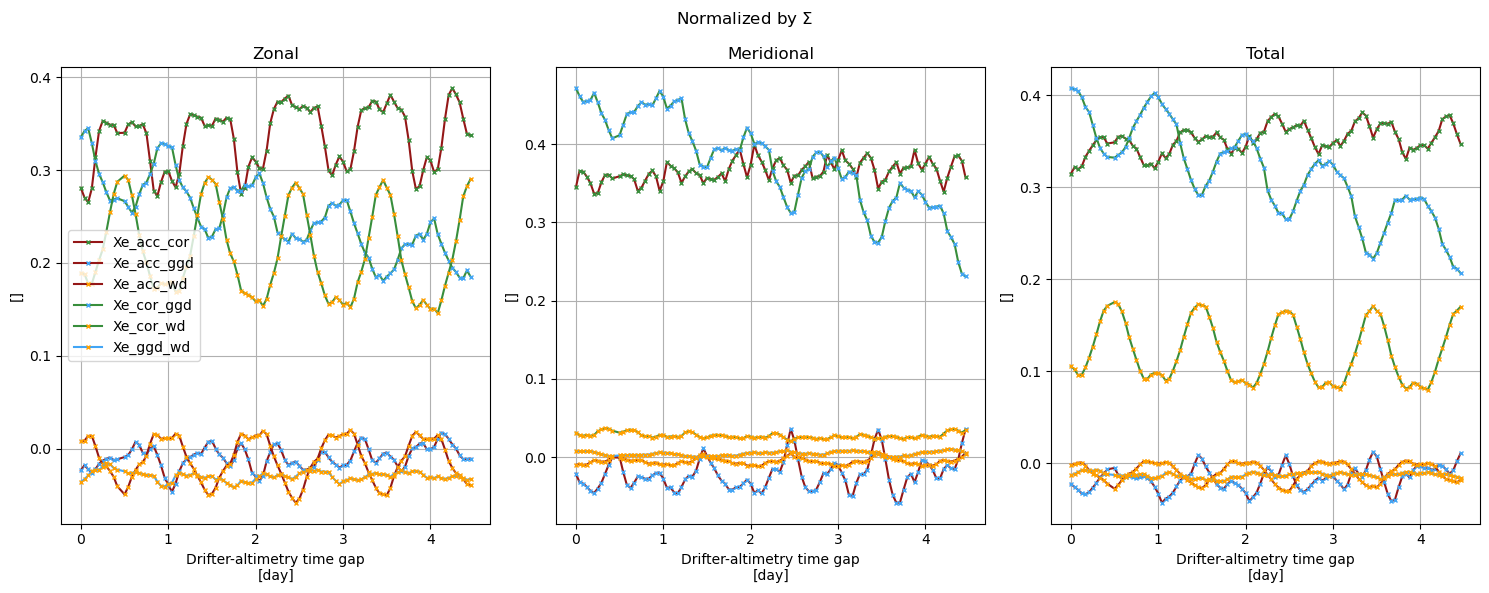

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(15,6))
axs =axs.flatten()
for xn in Xn:
    (ds[xn]/ds.sigman).plot(ax=axs[1], label=xn, **xstyle[xn.replace('Xn_', '')])
for xe in Xe:
    (ds[xe]/ds.sigmae).plot(ax=axs[0], label=xe, **xstyle[xe.replace('Xe_', '')])
i=0
for xn in Xn:
    ((ds[xn]+ds[Xe[i]])/(ds.sigman+ds.sigmae)).plot(ax=axs[2], label=xn, **xstyle[xn.replace('Xn_', '')])
    i+=1
    
fig.tight_layout()
for ax in axs:
    ax.grid()
    ax.set_ylabel(r'[]')
    
axs[0].legend()

axs[0].set_title('Zonal')
axs[1].set_title('Meridional')
axs[2].set_title('Total')

fig.suptitle(r'Normalized by $\Sigma$')
fig.tight_layout()

__________________
## Balanced signal contributions

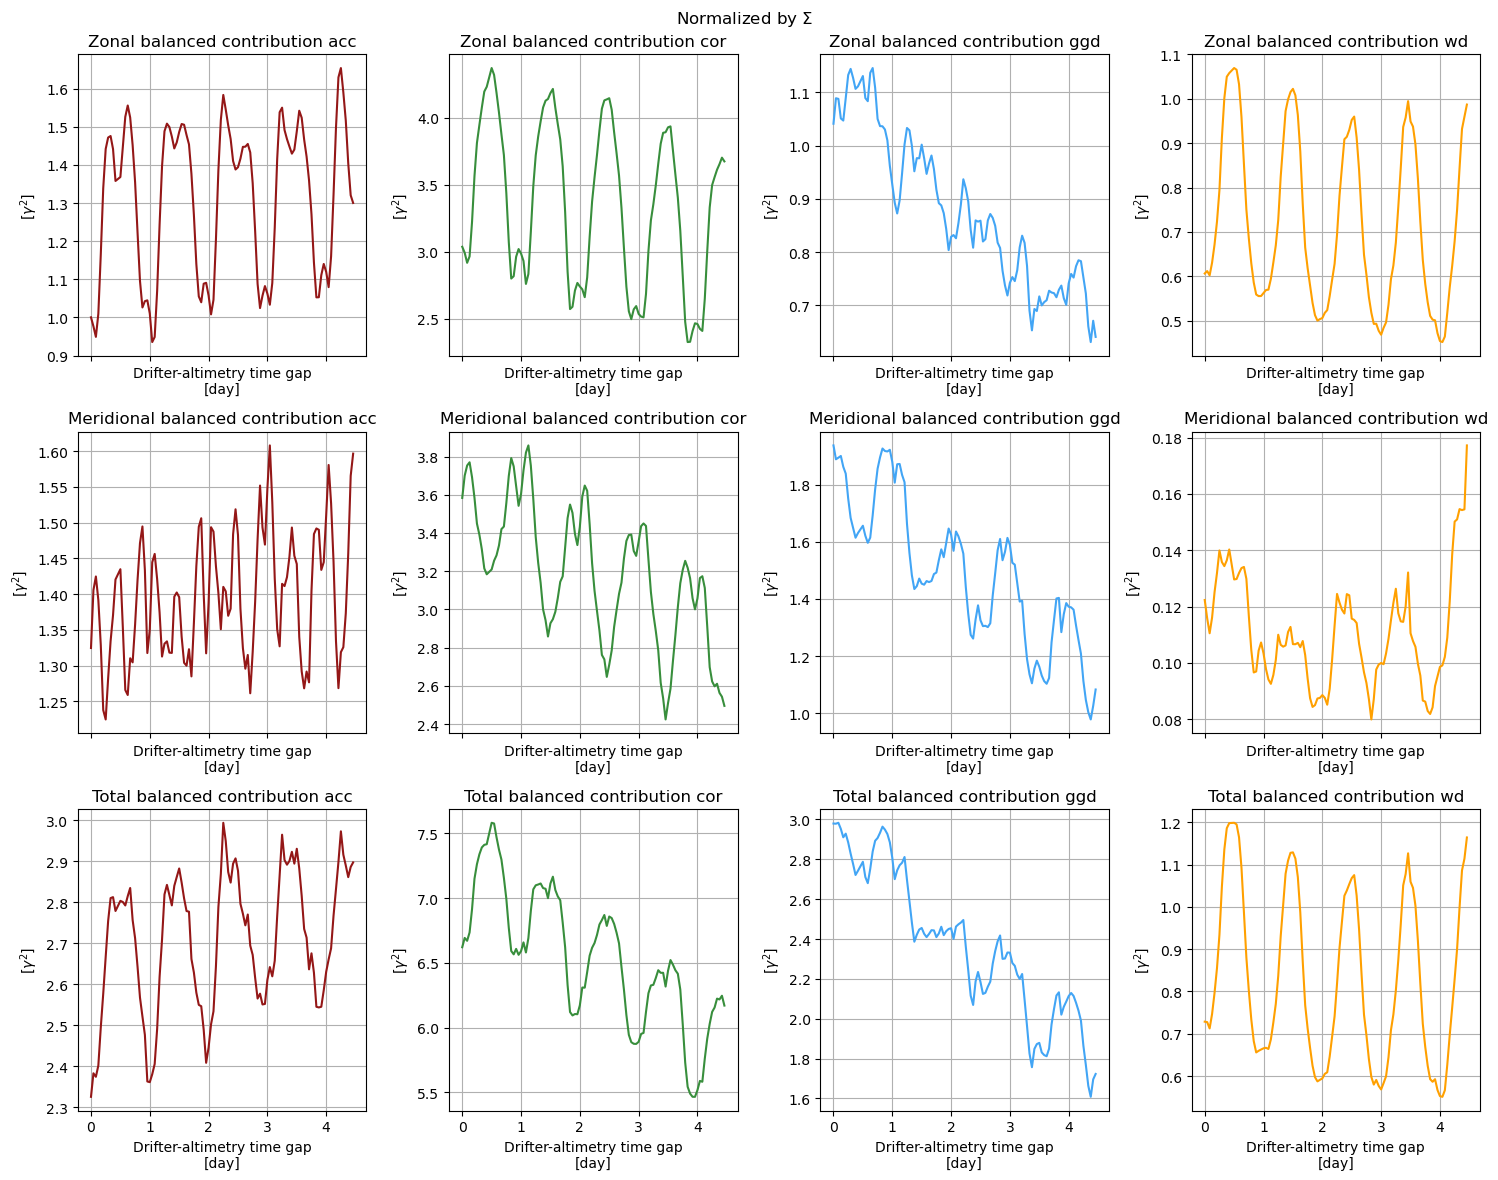

In [10]:
Bn = [k for k in ds.keys() if 'Bn' in k]
Be = [k for k in ds.keys() if 'Be' in k]

fig, axs = plt.subplots(3, 4, figsize=(15,12), sharex=True)
axs =axs.flatten()
i=0
for be in Be:
    ax=axs[i]
    ds[be].plot(ax=ax, label=be, color = c0[be.replace('Be_', '')])
    i+=1
    ax.set_title('Zonal balanced contribution ' + be.replace('Be_', ''))

for bn in Bn:
    ax=axs[i]
    ds[bn].plot(ax=ax, label=bn, color = c0[bn.replace('Bn_', '')])
    i+=1
    ax.set_title('Meridional balanced contribution ' + bn.replace('Bn_', ''))
    
for bn in Bn:
    ax=axs[i]
    (ds[bn] +ds[Be[i-8]]).plot(ax=ax, label=bn, color = c0[bn.replace('Bn_', '')])
    i+=1
    ax.set_title('Total balanced contribution ' + bn.replace('Bn_', ''))
    
fig.tight_layout()
for ax in axs:
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')

fig.suptitle(r'Normalized by $\Sigma$')
fig.tight_layout()

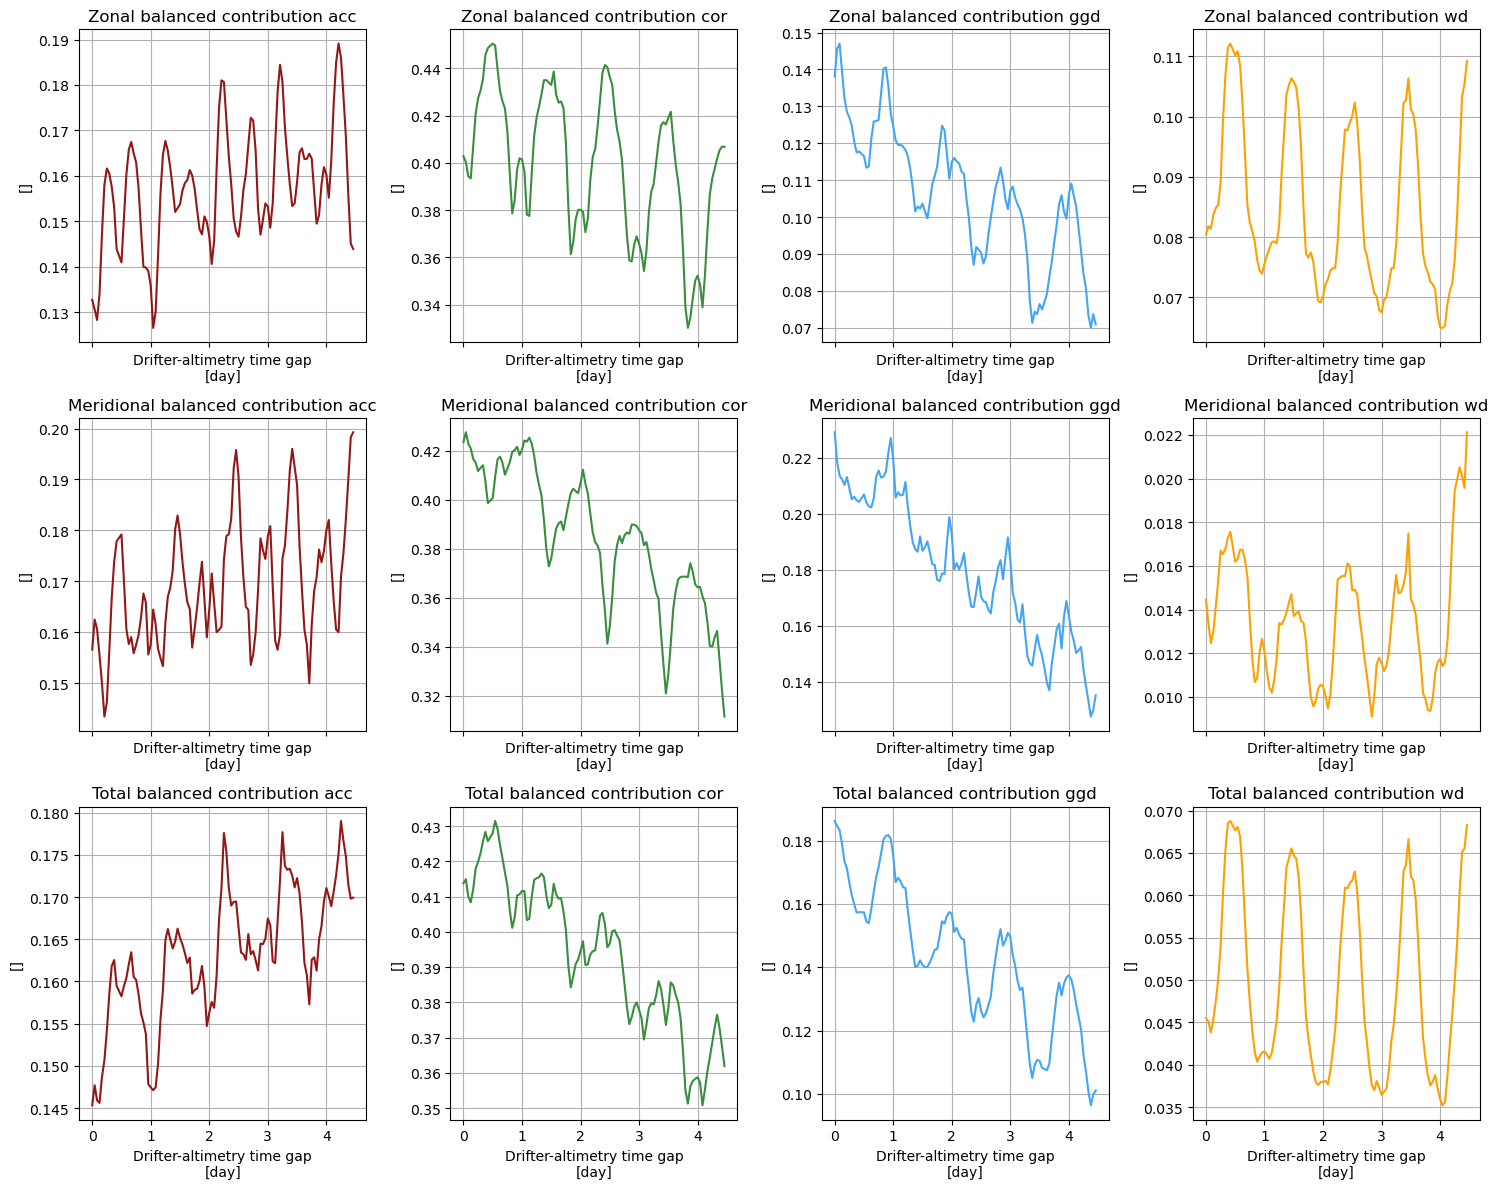

In [11]:
Bn = [k for k in ds.keys() if 'Bn' in k]
Be = [k for k in ds.keys() if 'Be' in k]

fig, axs = plt.subplots(3, 4, figsize=(15,12), sharex=True)
axs =axs.flatten()
i=0
for be in Be:
    ax=axs[i]
    (ds[be]/ds['sigmae']).plot(ax=ax, label=be, color = c0[be.replace('Be_', '')])
    i+=1
    ax.set_title('Zonal balanced contribution ' + be.replace('Be_', ''))

for bn in Bn:
    ax=axs[i]
    (ds[bn]/ds['sigman']).plot(ax=ax, label=bn, color = c0[bn.replace('Bn_', '')])
    i+=1
    ax.set_title('Meridional balanced contribution ' + bn.replace('Bn_', ''))
    
for bn in Bn:
    ax=axs[i]
    ((ds[bn] +ds[Be[i-8]])/(ds['sigman'] + ds['sigmae'])).plot(ax=ax, label=bn, color = c0[bn.replace('Bn_', '')])
    i+=1
    ax.set_title('Total balanced contribution ' + bn.replace('Bn_', ''))
    
fig.tight_layout()
for ax in axs:
    ax.grid()
    ax.set_ylabel(r'[]')
fig.tight_layout()

__________________
## Term variance

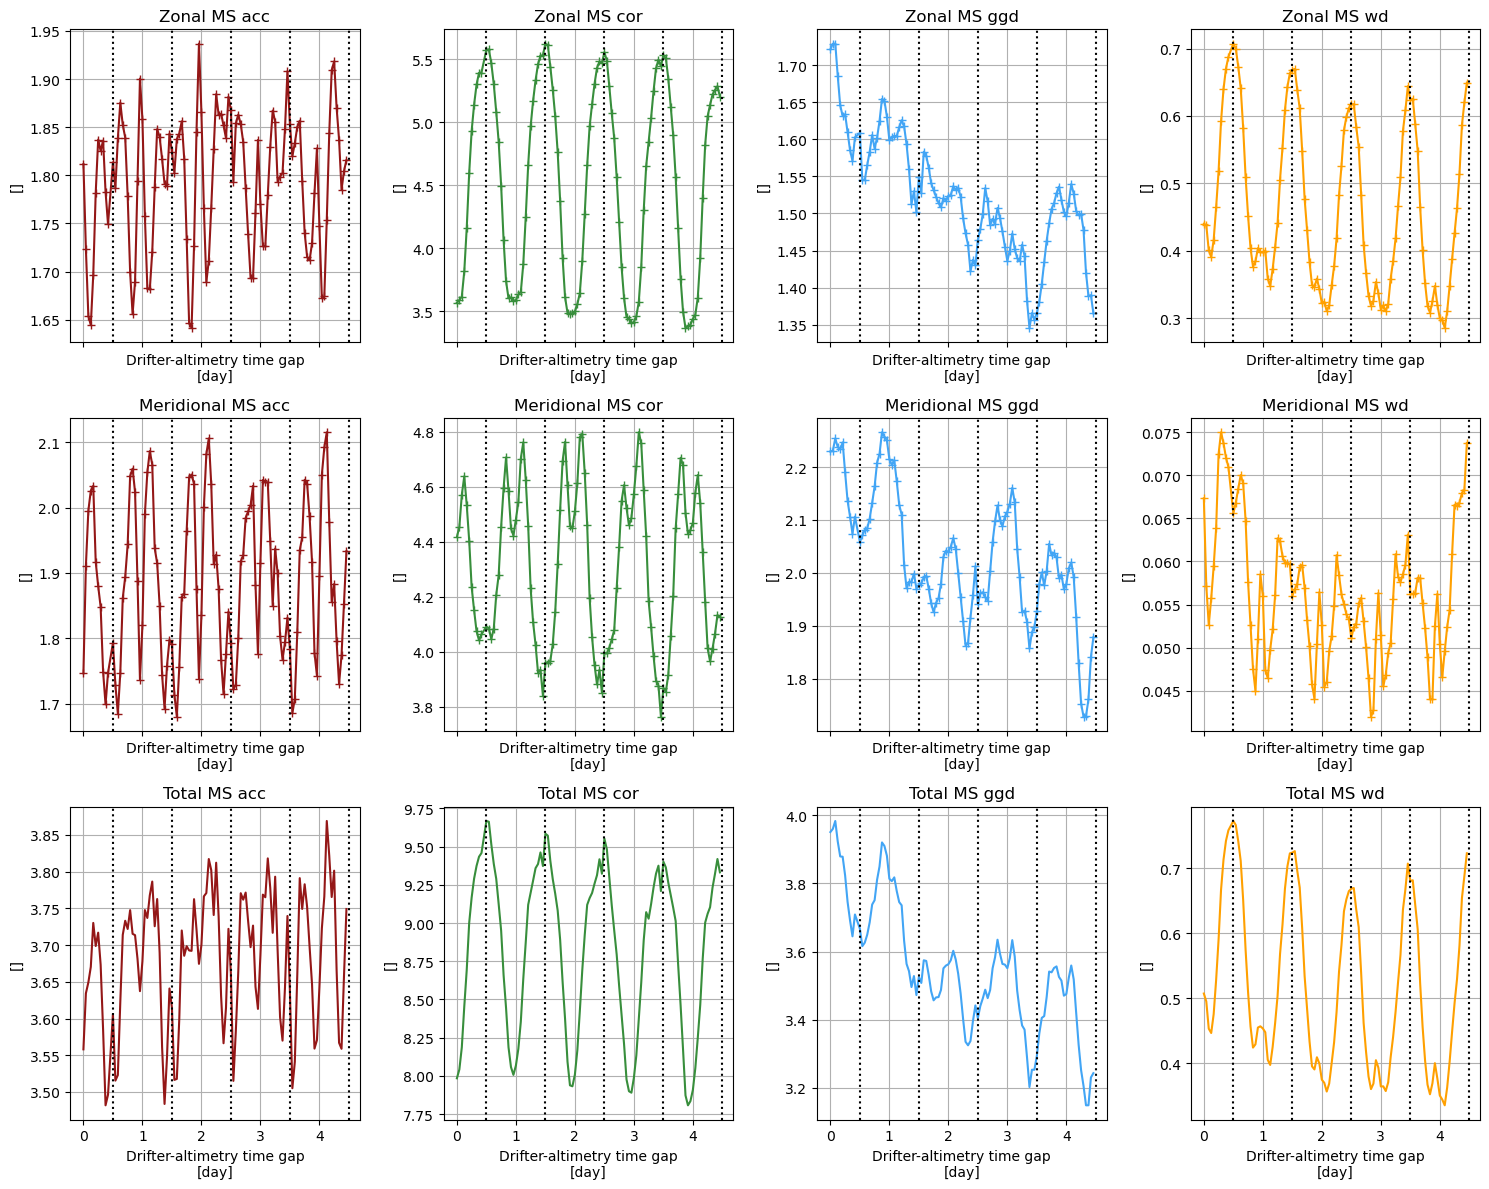

In [12]:
fig, axs = plt.subplots(3, 4, figsize=(15,12), sharex=True)
axs =axs.flatten()
i=0
var = ['acc', 'cor', 'ggd', 'wd']
for v in var :
    ax =axs[i]
    ds[v.upper() +'e'].plot(color=c0[v],marker='+', ax=ax)
    ax.set_title('Zonal MS ' + v)
    i+=1
for v in var :
    ax =axs[i]
    ds[v.upper() +'n'].plot(color=c0[v], marker='+',ax=ax)
    ax.set_title('Meridional MS ' + v)
    i+=1

for v in var :
    ax =axs[i]
    (ds[v.upper() +'e'] + ds[v.upper() +'n']).plot(color=c0[v], ax=ax)
    ax.set_title('Total MS ' + v)
    i+=1

for ax in axs:
    ax.grid()
    ax.set_ylabel(r'[]')
    ax.axvline(0.5, c = 'k', ls=':')
    ax.axvline(1.5, c = 'k', ls=':')
    ax.axvline(2.5, c = 'k', ls=':')
    ax.axvline(3.5, c = 'k', ls=':')
    ax.axvline(4.5, c = 'k', ls=':')
fig.tight_layout()

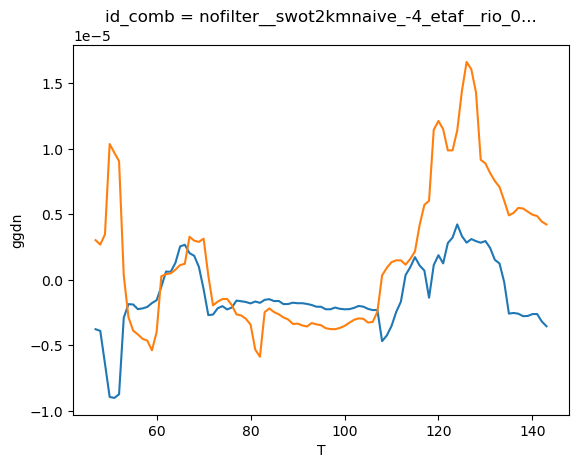

In [156]:
dss.mean('row_number').ggde.plot()
dss.mean('row_number').ggdn.plot()

In [159]:
Dm[0]

<xarray.Dataset> Size: 16kB
Dimensions:     (T: 48)
Coordinates:
    id_comb     <U38 152B 'nofilter__swot2kmnaive_etaf__rio_0era5'
  * T           (T) float64 384B 0.0 1.0 2.0 3.0 4.0 ... 44.0 45.0 46.0 47.0
Data variables: (12/41)
    ACCn        (T) float64 384B 1.746 1.911 1.995 ... 0.6793 0.6178 0.5992
    CORn        (T) float64 384B 4.416 4.454 4.57 4.637 ... 2.423 2.837 2.64
    GGDn        (T) float64 384B 2.229 2.231 2.254 2.238 ... 1.837 1.817 1.753
    WDn         (T) float64 384B 0.06733 0.05716 0.05264 ... 0.02646 0.02539
    Sn          (T) float64 384B 1.491 1.541 1.689 ... 0.9832 0.8152 0.6782
    ACCe        (T) float64 384B 1.812 1.724 1.654 1.644 ... 1.284 2.336 3.026
    ...          ...
    Xn_acc_ggd  (T) float64 384B -0.181 -0.2776 -0.3007 ... 0.8737 0.6362 0.4025
    Xn_acc_wd   (T) float64 384B -0.085 -0.07546 -0.08715 ... 0.07993 0.08527
    Xn_cor_ggd  (T) float64 384B 3.99 3.992 4.026 4.076 ... 3.144 3.787 3.802
    Xn_cor_wd   (T) float64 384B 0.262 0.2428 0.2431 ... 0.195 0.07558 0.02342
    Xn_ggd_wd   (T) float64 384B 0.06762 0.0642 0.06513 ... -0.1782 -0.1587
    nb_coloc    (T) int64 384B 6354 6369 6423 6402 6406 6381 ... 60 60 64 71 48

In [2]:
comb = dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0')
DS = dataset_coloc_combs([comb], nearest =False).dropna('row_number')

/Users/mdemol/code/med_analysis/diagnosis.py:71: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dfr = pd.read_csv(DRIFTER[drifter_key], parse_dates=['datetime', 'time_to_swot'], dtype=dtypes).set_index('row_number')


nofilter__swot2kmnaive_etaf__rio_0era5


In [11]:
a = DS.time_to_swot.astype('timedelta64[ns]') 
a.where(a/pd.Timedelta('1h') > 13, drop=True)

<xarray.DataArray 'time_to_swot' (id_comb: 1, row_number: 19366)> Size: 155kB
array([['0 days 13:05:26.278617920', '0 days 13:15:26.278617920',
        '0 days 13:25:26.278617920', ..., '0 days 13:29:51.131302592',
        '0 days 13:19:51.131302592', '0 days 13:09:51.131302592']],
      dtype=object)
Coordinates:
    datetime      (id_comb, row_number) datetime64[ns] 155kB 2023-04-21T09:50...
    longitude     (id_comb, row_number) float64 155kB 4.857 4.857 ... 2.231 2.23
    latitude      (id_comb, row_number) float64 155kB 40.13 40.13 ... 38.65
    pass_number   (id_comb, row_number) int64 155kB 3 3 3 3 3 ... 16 16 16 16 16
    time_to_swot  (id_comb, row_number) object 155kB '0 days 13:05:26.2786179...
    cycle_number  (id_comb, row_number) int64 155kB 497 497 497 ... 535 535 535
    drifter_id    (id_comb, row_number) object 155kB '300534060113380' ... '4...
    drifter_type  (id_comb, row_number) object 155kB 'SVP' 'SVP' ... 'CARTHE'
    depth         (id_comb, row_number) int64 155kB 50 50 50 50 50 ... 0 0 0 0 0
  * row_number    (row_number) int64 155kB 47119 47120 47121 ... 330121 330122
  * id_comb       (id_comb) <U38 152B 'nofilter__swot2kmnaive_etaf__rio_0era5'

In [7]:
DS.time_to_swot/pd.Timedelta('1h')

<xarray.DataArray 'time_to_swot' (id_comb: 1, row_number: 290395)> Size: 2MB
array([[11.87574904, 11.70908237, 11.5424157 , ..., 11.5605921 ,
        11.72725876, 11.89392543]])
Coordinates:
    datetime      (id_comb, row_number) datetime64[ns] 2MB 2023-04-01T11:50:0...
    longitude     (id_comb, row_number) float64 2MB 4.812 4.812 ... 2.415 2.414
    latitude      (id_comb, row_number) float64 2MB 42.22 42.22 ... 39.79 39.79
    pass_number   (id_comb, row_number) int64 2MB 3 3 3 3 3 3 ... 16 16 16 16 16
    time_to_swot  (id_comb, row_number) object 2MB '0 days 11:52:32.696536' ....
    cycle_number  (id_comb, row_number) int64 2MB 478 478 478 ... 577 577 577
    drifter_id    (id_comb, row_number) object 2MB '300534060315840' ... '300...
    drifter_type  (id_comb, row_number) object 2MB 'SVP' 'SVP' ... 'SVP' 'SVP'
    depth         (id_comb, row_number) int64 2MB 15 15 15 15 15 ... 15 15 15 15
  * row_number    (row_number) int64 2MB 0 1 2 3 ... 383259 383260 383261 383262
  * id_comb       (id_comb) <U38 152B 'nofilter__swot2kmnaive_etaf__rio_0era5'